# 09. English conflict-over-topic: 240 новых троек

**Цель:** проверить, помогает ли фиксированный концепт-профиль находить одинаковый конфликт вопреки тематическому отвлечению. 720 новых английских абзацев; 240 уникальных троек A/B/C, без повторного использования текстов. Три прежних примера исключены.

Модель Dilemma — **paraphrase-multilingual-MiniLM-L12-v2, 384D**. Сравниваем embedding, concept207 и hybrid50. Основная разность — hybrid50 − embedding по точности предпочтения d(A,B)<d(A,C). Все другие исходы и случайные контроли также опубликованы.

[Протокол](PROTOCOL.md), [поправка до scoring](PRE_SCORE_AMENDMENT.md), [читаемый отчёт](research_note.md). Набор и аудиты подготовлены с AI-помощью, без человеческого gold standard.


## Полученный результат

На **240 новых английских тройках (720 уникальных абзацев)** обычный embedding дал **111/240 (46.25%)**, concept207 — **145/240 (60.42%)**, hybrid50 — **133/240 (55.42%)**.

Главная разность **hybrid50 − embedding = +9.17 п.п.**, описательный двухфакторный 95% интервал **[+0.42; +19.58] п.п.** Рабочий ориентир «не менее +5 п.п. и нижняя граница выше нуля» **достигнут**. Модель — та же, что указана в Dilemma: **multilingual MiniLM, 384D**.

Смесь с концептами превысила 95-й percentile обеих случайных контрольных семей по заранее заданному описательному сравнению. Это ограниченный результат на выбранных картах и корпусе, а не p-value или доказательство механизма.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display,Markdown
from experiment import BASE,DATA,RESULTS,METHODS,run,verify_freeze
pd.set_option('display.max_columns',None);pd.set_option('display.max_colwidth',110)
plt.rcParams.update({'figure.dpi':115,'axes.spines.top':False,'axes.spines.right':False})
manifest=verify_freeze()
display(Markdown('Входы фиксированы до первого нового scoring: **'+manifest['frozen_at_utc']+'**.'))
rows,tables,environment=run()
main,summary,intervals=tables['per_triplet'],tables['summary'],tables['intervals']
FIG=RESULTS/'figures';FIG.mkdir(exist_ok=True)


Входы фиксированы до первого нового scoring: **2026-09-09T15:29:08.553943+00:00**.

Encoding 720 English paragraphs with the fixed Dilemma model.


<python-environment>/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6798.95it/s]

    method  n_triplets  correct_score  accuracy  mean_margin
concept207         240          145.0  0.604167     0.056505
 embedding         240          111.0  0.462500    -0.011749
  hybrid50         240          133.0  0.554167     0.022378


    method   baseline           grouping   metric  difference       low      high
  hybrid50  embedding conflict_and_topic accuracy    0.091667  0.004167  0.195833
  hybrid50  embedding           conflict accuracy    0.091667  0.037500  0.141667
  hybrid50  embedding       anchor_topic accuracy    0.091667  0.033333  0.154167
concept207  embedding conflict_and_topic accuracy    0.141667  0.025000  0.270833
concept207  embedding           conflict accuracy    0.141667  0.079167  0.208333
concept207  embedding       anchor_topic accuracy    0.141667  0.054167  0.229167
  hybrid50 concept207 conflict_and_topic accuracy   -0.050000 -0.125000  0.025000
  hybrid50 concept207           conflict accuracy   -0.050000 -0.091667 -0.008333
  hybrid50 concept207       anchor_topic accuracy   -0.050000 -0.095833 -0.004167


## Набор и два аудита до scoring

12 конфликтов × 10 тем × 2 варианта. Четыре AI-авторские последовательности по 60 троек. Первые большие шаблонные генерации отклонены **до** аудитов и embeddings; окончательные тексты написаны по 12 троек отдельными буквальными историями. Изменение процедуры раскрыто в поправке, исходный дизайн сохранён.

Аудиторы получили только A, X, Y со случайным порядком кандидатов, без ролей B/C, авторских классов, тем и scores. Они выбирали совпадение основных конкурирующих ставок: X, Y, both или neither. Ни аудиторское согласие, ни общий размер корпуса не устраняют зависимость AI-стиля и размеченных определений.

До scoring обнаружены несоответствия буквы тексту объяснения. Для каждого исходного аудита отдельный AI-проверяющий сверил кодирование всех ответов без раскрытия ключей; первоначальные объяснения и версии сохранены. Процедура, неудачная промежуточная попытка и начальные согласия раскрыты в [отдельном уточнении](PRE_SCORE_AUDIT_REPAIR.md); итоговый отчёт показывает чувствительность и по первым ответам. Это дополнительная проверка, не ещё два независимых смысловых голоса.


In [2]:
display(pd.crosstab(rows.conflict,rows.anchor_topic))
display(tables['audit_by_conflict'])
display(Markdown(f"Аудитор 1 согласился с автором: **{environment['auditor_1_agrees_count']}/240**; аудитор 2: **{environment['auditor_2_agrees_count']}/240**; оба: **{environment['both_audits_agree_count']}/240**."))
display(pd.crosstab(rows.audit_1,rows.audit_2))
display(rows.loc[~rows.both_audits_agree,['id','conflict','anchor_topic','audit_1','audit_2']].head(30))
display(Markdown('Всего **720 уникальных английских текстов**. Максимальная длина: **'+str(max(environment['token_lengths']))+' токенов**, лимит 128.'))


anchor_topic,agriculture,arts,community_projects,education,healthcare,public_services,science,small_business,software,sport
conflict,,,,,,,,,,
ambition_vs_belonging,2,2,2,2,2,2,2,2,2,2
autonomy_vs_approval,2,2,2,2,2,2,2,2,2,2
change_vs_tradition,2,2,2,2,2,2,2,2,2,2
discipline_vs_comfort,2,2,2,2,2,2,2,2,2,2
fairness_vs_mercy,2,2,2,2,2,2,2,2,2,2
freedom_vs_safety,2,2,2,2,2,2,2,2,2,2
health_vs_duty,2,2,2,2,2,2,2,2,2,2
personal_gain_vs_collective_impact,2,2,2,2,2,2,2,2,2,2
privacy_vs_openness,2,2,2,2,2,2,2,2,2,2


,conflict,n,auditor_1_agrees,auditor_2_agrees,both_agree
0,ambition_vs_belonging,20,20,20,20
1,autonomy_vs_approval,20,19,19,18
2,change_vs_tradition,20,20,20,20
3,discipline_vs_comfort,20,20,20,20
4,fairness_vs_mercy,20,17,18,15
5,freedom_vs_safety,20,19,20,19
6,health_vs_duty,20,18,20,18
7,personal_gain_vs_collective_impact,20,19,20,19
8,privacy_vs_openness,20,19,20,19
9,quality_vs_speed,20,20,19,19


Аудитор 1 согласился с автором: **229/240**; аудитор 2: **236/240**; оба: **225/240**.

audit_2,B,C
audit_1,,
B,225,4
C,10,0
neither,1,0


,id,conflict,anchor_topic,audit_1,audit_2
11,e149232,personal_gain_vs_collective_impact,arts,C,B
31,e224123,fairness_vs_mercy,agriculture,C,B
35,e239295,fairness_vs_mercy,arts,B,C
64,e372525,fairness_vs_mercy,public_services,neither,B
68,e385608,privacy_vs_openness,agriculture,C,B
69,e393194,fairness_vs_mercy,small_business,B,C
88,e460139,autonomy_vs_approval,public_services,C,B
109,e541035,health_vs_duty,arts,C,B
136,e660306,quality_vs_speed,software,B,C
137,e661245,security_vs_care,arts,C,B


Всего **720 уникальных английских текстов**. Максимальная длина: **98 токенов**, лимит 128.

## Геометрия и основная метрика

$$z=\operatorname{norm}(encoder(text)),\quad c=\operatorname{norm}(z(A-\operatorname{mean}_{rows}A)^T),\quad h=[\sqrt{0.5}z;\sqrt{0.5}c].$$

A — та же карта 207 атрибутов Bhatia. Encoder и карта не обучаются на новых метках. Размерности: z — 384, c — 207, h — 591. Расстояние hybrid равно среднему двух расстояний компонентов.

Положительный $m=d(A,C)-d(A,B)$ означает правильное предпочтение одинакового конфликта, отрицательный — предпочтение темы. Точное равенство даёт 0.5 балла. Основная точность — средний балл по 240 тройкам. Margin описателен и не является калиброванной уверенностью.


,method,n_triplets,correct_score,accuracy,mean_margin
0,concept207,240,145.0,0.60417,0.05651
1,embedding,240,111.0,0.46250,-0.01175
2,hybrid50,240,133.0,0.55417,0.02238


,method,baseline,improved_triplets,worsened_triplets,unchanged_triplets
0,hybrid50,embedding,36,14,190
1,concept207,embedding,55,21,164
2,hybrid50,concept207,7,19,214


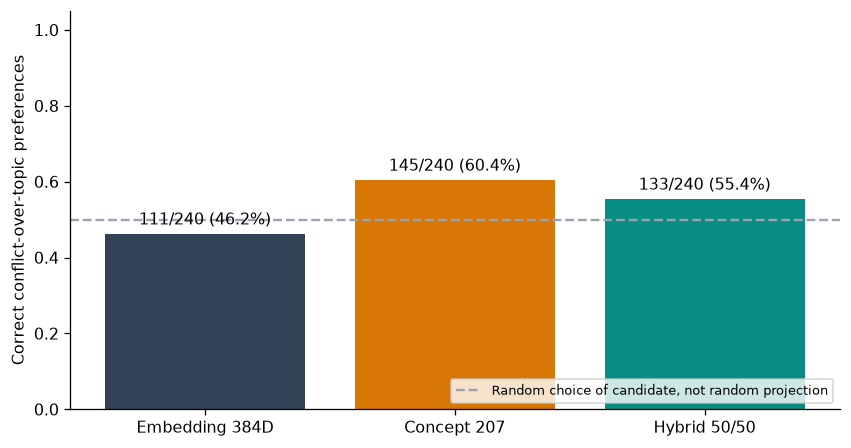

In [3]:
display(summary.round(5))
display(tables['transitions'])
fig,ax=plt.subplots(figsize=(7.5,4))
s=summary.set_index('method').loc[METHODS]
ax.bar(['Embedding 384D','Concept 207','Hybrid 50/50'],s.accuracy,color=['#334155','#d97706','#078d82'])
for i,r in enumerate(s.itertuples()):ax.text(i,r.accuracy+.025,f'{r.correct_score:g}/240 ({r.accuracy:.1%})',ha='center')
ax.set_ylim(0,1.05);ax.set_ylabel('Correct conflict-over-topic preferences')
ax.axhline(.5,color='#9ca3af',linestyle='--',label='Random choice of candidate, not random projection')
ax.legend(fontsize=8,loc='lower right');fig.tight_layout();fig.savefig(FIG/'accuracy.png',dpi=180);plt.show()


## Разности и устойчивость

Основной 95% интервал: 10 000 парных двухфакторных bootstrap-перевзвешиваний 12 конфликтов и 10 anchor-тем, оба варианта клетки сохраняются. Дополнительно — группировки по одному фактору и исключение каждого из четырёх авторов. Это описательная чувствительность фиксированной синтетической сетки, не population CI.

Рабочий ориентир +5 п.п. и нижняя граница основного интервала выше нуля был зафиксирован как **допущение ассистента**, поскольку вопрос о пороге остался без ответа. Точные числа публикуются независимо от его достижения.


,method,baseline,grouping,metric,difference,low,high
0,hybrid50,embedding,conflict_and_topic,accuracy,0.09167,0.00417,0.19583
2,hybrid50,embedding,conflict,accuracy,0.09167,0.03750,0.14167
4,hybrid50,embedding,anchor_topic,accuracy,0.09167,0.03333,0.15417


,method,baseline,grouping,metric,difference,low,high
0,hybrid50,embedding,conflict_and_topic,accuracy,0.09167,0.00417,0.19583
2,hybrid50,embedding,conflict,accuracy,0.09167,0.03750,0.14167
4,hybrid50,embedding,anchor_topic,accuracy,0.09167,0.03333,0.15417
6,concept207,embedding,conflict_and_topic,accuracy,0.14167,0.02500,0.27083
8,concept207,embedding,conflict,accuracy,0.14167,0.07917,0.20833
10,concept207,embedding,anchor_topic,accuracy,0.14167,0.05417,0.22917
12,hybrid50,concept207,conflict_and_topic,accuracy,-0.05000,-0.12500,0.02500
14,hybrid50,concept207,conflict,accuracy,-0.05000,-0.09167,-0.00833
16,hybrid50,concept207,anchor_topic,accuracy,-0.05000,-0.09583,-0.00417


,method,baseline,excluded_author,n_triplets,accuracy_difference,margin_difference
0,hybrid50,embedding,0,180,0.07222,0.03420
1,hybrid50,embedding,1,180,0.11111,0.04194
2,hybrid50,embedding,2,180,0.08333,0.03337
3,hybrid50,embedding,3,180,0.10000,0.02699
4,concept207,embedding,0,180,0.13889,0.06840
5,concept207,embedding,1,180,0.17222,0.08388
6,concept207,embedding,2,180,0.13333,0.06675
7,concept207,embedding,3,180,0.12222,0.05399
8,hybrid50,concept207,0,180,-0.06667,-0.03420
9,hybrid50,concept207,1,180,-0.06111,-0.04194


method,concept207,embedding,hybrid50,hybrid_minus_embedding
conflict,,,,
ambition_vs_belonging,0.65,0.30,0.55,0.25
autonomy_vs_approval,0.40,0.30,0.35,0.05
change_vs_tradition,0.60,0.60,0.60,0.00
discipline_vs_comfort,0.65,0.65,0.65,0.00
fairness_vs_mercy,0.75,0.65,0.75,0.10
freedom_vs_safety,0.50,0.45,0.35,-0.10
health_vs_duty,0.65,0.35,0.50,0.15
personal_gain_vs_collective_impact,0.50,0.30,0.45,0.15
privacy_vs_openness,0.55,0.40,0.55,0.15


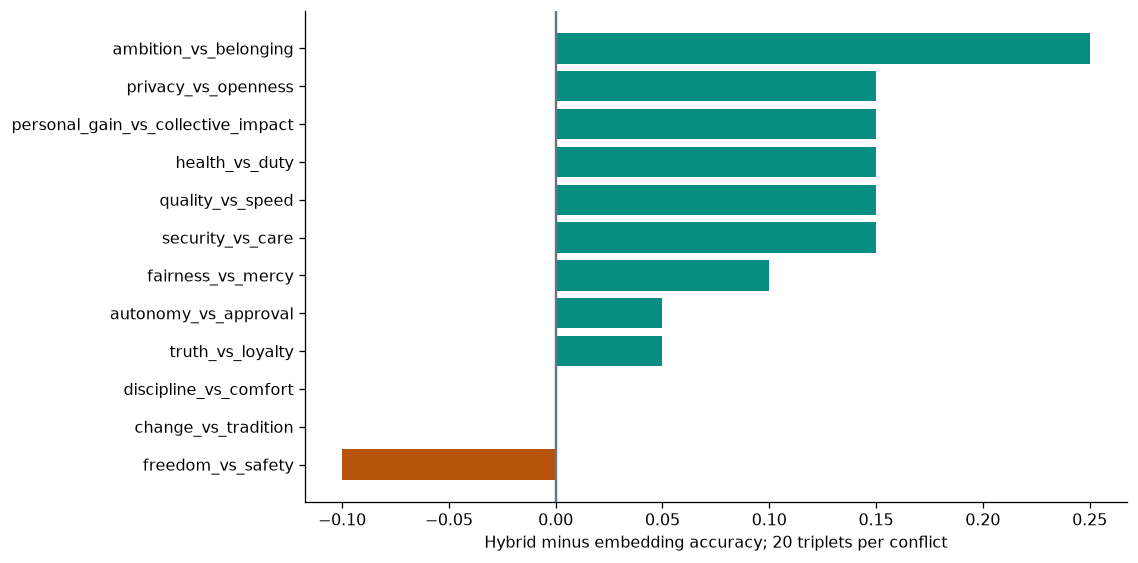

,method,n_triplets,correct_score,accuracy,mean_margin,n_conflicts,n_topics,interpretable
0,concept207,225,133.0,0.59111,0.05295,12,10,True
1,embedding,225,104.0,0.46222,-0.01211,12,10,True
2,hybrid50,225,123.0,0.54667,0.02042,12,10,True


In [4]:
primary=intervals[(intervals.method=='hybrid50')&(intervals.baseline=='embedding')&(intervals.metric=='accuracy')]
display(primary.round(5))
display(intervals[intervals.metric.eq('accuracy')].round(5))
display(tables['leave_one_author_out'].round(5))
by_conflict=main.groupby(['conflict','method']).score.mean().unstack()
by_conflict['hybrid_minus_embedding']=by_conflict.hybrid50-by_conflict.embedding
display(by_conflict.round(4))
fig,ax=plt.subplots(figsize=(10,5))
delta=by_conflict.hybrid_minus_embedding.sort_values()
ax.barh(delta.index,delta.values,color=['#b45309' if v<0 else '#078d82' for v in delta])
ax.axvline(0,color='#64748b');ax.set_xlabel('Hybrid minus embedding accuracy; 20 triplets per conflict')
fig.tight_layout();fig.savefig(FIG/'conflict_differences.png',dpi=180);plt.show()
display(tables['agreed_audit_sensitivity'].round(5))


## Случайные карты

30 Gaussian-проекций в 207 координат и 30 случайных ориентаций с тем же спектром, что у концепт-карты. Для каждой — отдельный профиль и его смесь 50/50 с z. Все seeds назначены до scores. Карты используют тот же семантический embedding, поэтому их точность не обязана равняться 50%.

Доли превышений и 95-й percentile здесь описывают выбранные карты на **тех же** 240 тройках: это не p-values и не 60 независимых датасетов. Прирост относительно embedding и преимущество над случайными картами — разные утверждения.


,family,blend,n_maps,accuracy_min,accuracy_median,accuracy_p95,accuracy_max,n_accuracy_strictly_above_concept,n_accuracy_equal_concept,margin_min,margin_median,margin_max
0,gaussian,hybrid50,30,0.42500,0.46667,0.49167,0.49583,0,0,-0.02184,-0.01279,-0.00693
1,gaussian,projection,30,0.40417,0.47292,0.49396,0.53750,0,0,-0.03193,-0.01384,-0.00212
2,spectrum_matched,hybrid50,30,0.40000,0.46042,0.51479,0.55833,1,0,-0.03971,-0.01590,0.02232
3,spectrum_matched,projection,30,0.39167,0.46458,0.53979,0.55833,0,0,-0.06767,-0.02005,0.05638


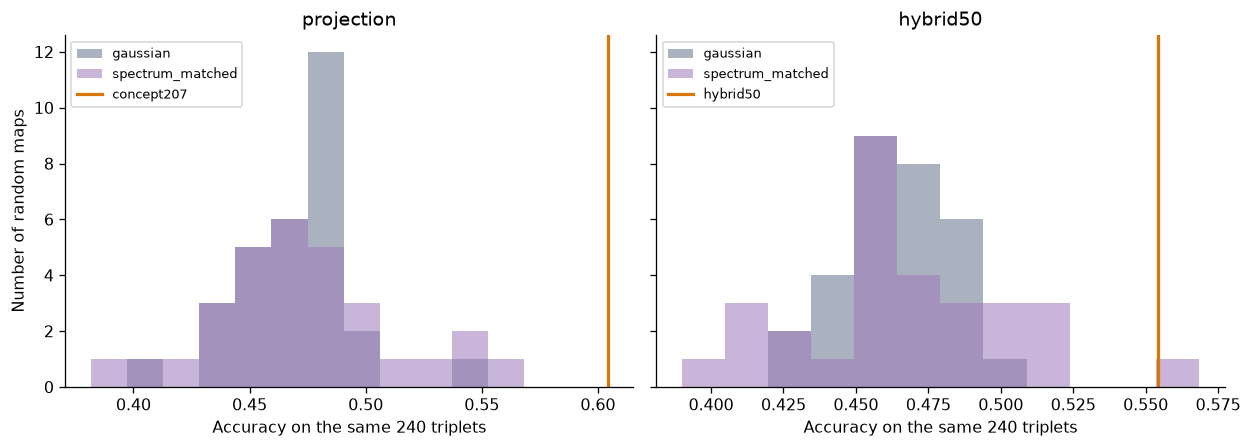

In [5]:
display(tables['random_distributions'].round(5))
controls=tables['random_summary']
fig,axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,blend,target in zip(axes,['projection','hybrid50'],['concept207','hybrid50']):
    sub=controls[controls.blend.eq(blend)]
    bins=np.linspace(sub.accuracy.min()-.01,sub.accuracy.max()+.01,13)
    for family,color in [('gaussian','#64748b'),('spectrum_matched','#9d78ba')]:
        ax.hist(sub[sub.family.eq(family)].accuracy,bins=bins,alpha=.55,label=family,color=color)
    ax.axvline(float(summary[summary.method.eq(target)].accuracy.iloc[0]),color='#d97706',linewidth=2,label=target)
    ax.set_title(blend);ax.set_xlabel('Accuracy on the same 240 triplets');ax.legend(fontsize=8)
axes[0].set_ylabel('Number of random maps');fig.tight_layout();fig.savefig(FIG/'random_controls.png',dpi=180);plt.show()


## Примеры без отбора по результату

Три минимальных случайных ID из зафиксированного корпуса. Это иллюстрация, а не отдельное доказательство. Все остальные абзацы сохранены в `data/triplets.json`; все спорные оценки аудиторов доступны в исходных JSON.


In [6]:
for r in rows.head(3).to_dict('records'):
    display(Markdown('### '+r['id']+' — '+r['conflict']))
    for role in ['A','B','C']:display(Markdown('**'+role+'** — '+r[role]))
    display(main[main.id.eq(r['id'])][['method','d_same_conflict','d_same_topic','margin','score']].round(5))
verify_freeze()
assert len(main)==720 and len(tables['random_per_triplet'])==28800
display(Markdown('Все 240 троек × 3 основных метода и 28 800 контрольных оценок сохранены. Итог и ограничения: [research_note.md](research_note.md).'))


### e104500 — privacy_vs_openness

**A** — The owner of a bicycle shop has epilepsy controlled by medication. Telling his mechanics could help them respond calmly if he has a seizure and create greater trust, but it would disclose a diagnosis that customers might hear about and misunderstand. Should he discuss his condition with the staff?

**B** — A resident coordinating repairs to a shared apartment courtyard lacks permanent immigration status. Disclosing this to the volunteer committee could explain why she avoids official forms and allow others to help, yet it would reveal sensitive information that might travel beyond trusted neighbors. Should she tell the committee?

**C** — A chef can spend her savings on a monthlong midnight pop-up where every menu depends on ingredients found that day, with uncertain attendance and room for discovery. A corporate lunch contract offers guaranteed revenue, insured kitchens, and fixed recipes. Which opportunity should she choose?

,method,d_same_conflict,d_same_topic,margin,score
0,embedding,0.70271,0.69912,-0.00359,0.0
240,concept207,0.74951,0.65033,-0.09918,0.0
480,hybrid50,0.72611,0.67473,-0.05138,0.0


...

**A** — Organizer Julie can rent the community festival grounds to a private car show for a personal commission. Hundreds of vehicles would idle during demonstrations, bringing noise and exhaust to surrounding homes and a nearby school, while the payment would clear her debts. Should Julie secure the profitable booking or refuse because neighbors would bear the disruption?

**B** — Hospital buyer Kofi is offered a personal bonus by a supplier if his clinic switches to individually packaged disposable gowns. The contract rewards him and simplifies storage, but it creates far more plastic waste and disposal costs shared by patients and the municipality. Should Kofi choose the bonus-paying supplier or retain reusable gowns to reduce the collective burden?

**C** — A community workshop suspends anyone who damages equipment through prohibited use. Coordinator Lena learns that a refugee member broke a saw while building emergency furniture for his family and cannot afford private tools, though previous violators served suspensions. Should Lena waive the penalty because of his hardship or enforce the same rule for every member?

,method,d_same_conflict,d_same_topic,margin,score
2,embedding,0.69459,0.55778,-0.13682,0.0
242,concept207,0.55809,0.34093,-0.21716,0.0
482,hybrid50,0.62634,0.44935,-0.17699,0.0


Все 240 троек × 3 основных метода и 28 800 контрольных оценок сохранены. Итог и ограничения: [research_note.md](research_note.md).